In [1]:
# ============================================================
# Configuração do projeto
# ============================================================

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# ============================================================
# Importando funções
# ============================================================

from src.preprocessing import create_preprocessor

preprocessor = create_preprocessor()

# ============================================================
# Pacotes
# ============================================================

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# Leitura dos dados
# ============================================================

df = pd.read_excel(
    PROJECT_ROOT / "data/raw/default_of_credit_card_clients.xls",
    header=1
)

# Removendo coluna ID
df = df.drop(columns=["ID"])

# Renomeando target
df = df.rename(
    columns={"default payment next month": "default"}
)

# ============================================================
# Variáveis
# ============================================================

X = df.drop(columns="default")
y = df["default"]

# ============================================================
# Train Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# Modelo
# ============================================================

random_forest = RandomForestClassifier(
    random_state=42
)

# ============================================================
# Pipeline
# ============================================================

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", random_forest)
    ]
)

# ============================================================
# Treinamento
# ============================================================

rf_pipeline.fit(X_train, y_train)

# ============================================================
# Salvando modelo
# ============================================================

Path(PROJECT_ROOT / "models").mkdir(exist_ok=True)

joblib.dump(
    rf_pipeline,
    PROJECT_ROOT / "models/random_forest_baseline.pkl"
)

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


Random Forest - Baseline
Accuracy : 0.8135
Precision: 0.6337
Recall   : 0.3715
F1 Score : 0.4684
ROC AUC  : 0.7546

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.37      0.47      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.66      0.68      6000
weighted avg       0.79      0.81      0.79      6000



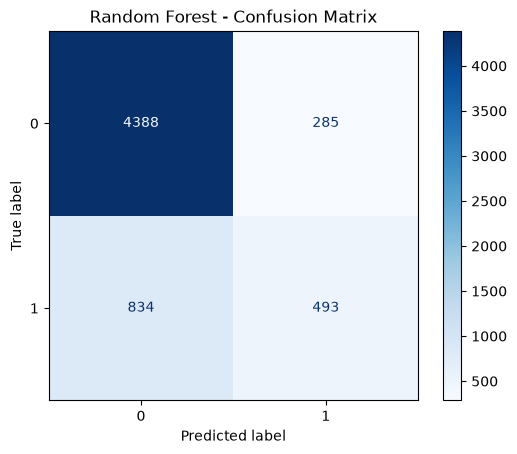

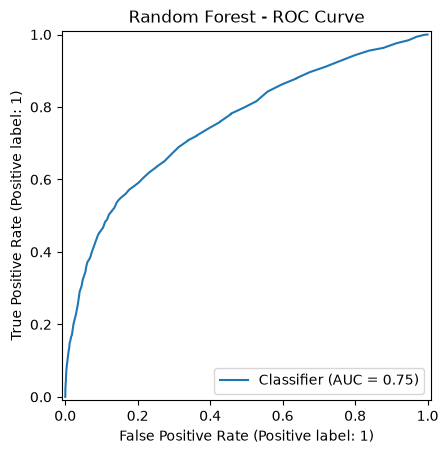

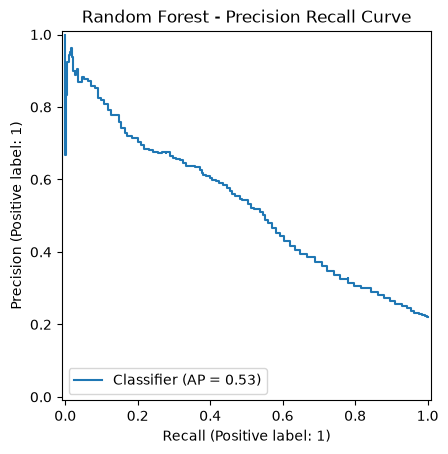


Generalização do Modelo
Accuracy Treino : 0.9995
Accuracy Teste  : 0.8135

ROC AUC Treino  : 1.0000
ROC AUC Teste   : 0.7546

Gap Accuracy : 0.1860
Gap ROC AUC  : 0.2454

⚠️ Possível overfitting detectado.


In [2]:
# ============================================================
# Avaliação da Random Forest
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# ============================================================
# Predições
# ============================================================

y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:,1]

train_pred = rf_pipeline.predict(X_train)
train_prob = rf_pipeline.predict_proba(X_train)[:,1]

# ============================================================
# Métricas
# ============================================================

print("="*50)
print("Random Forest - Baseline")
print("="*50)

print(f"Accuracy : {accuracy_score(y_test,y_pred):.4f}")
print(f"Precision: {precision_score(y_test,y_pred):.4f}")
print(f"Recall   : {recall_score(y_test,y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test,y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test,y_prob):.4f}")

# ============================================================
# Classification Report
# ============================================================

print()
print("="*50)
print("Classification Report")
print("="*50)

print(classification_report(y_test,y_pred))

# ============================================================
# Confusion Matrix
# ============================================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

# ============================================================
# ROC Curve
# ============================================================

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Random Forest - ROC Curve")
plt.show()

# ============================================================
# Precision Recall Curve
# ============================================================

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Random Forest - Precision Recall Curve")
plt.show()

# ============================================================
# Generalização
# ============================================================

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, y_pred)

train_auc = roc_auc_score(y_train, train_prob)
test_auc = roc_auc_score(y_test, y_prob)

print()
print("="*50)
print("Generalização do Modelo")
print("="*50)

print(f"Accuracy Treino : {train_acc:.4f}")
print(f"Accuracy Teste  : {test_acc:.4f}")

print()

print(f"ROC AUC Treino  : {train_auc:.4f}")
print(f"ROC AUC Teste   : {test_auc:.4f}")

print()

print(f"Gap Accuracy : {train_acc-test_acc:.4f}")
print(f"Gap ROC AUC  : {train_auc-test_auc:.4f}")

if (train_acc-test_acc) > 0.10:
    print("\n⚠️ Possível overfitting detectado.")
else:
    print("\n✅ Não foram encontrados indícios fortes de overfitting.")

In [1]:
# ==================================================
# Random Forest - Grid Search
# ==================================================

import os
import sys
import joblib
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# ==================================================
# Configuração do projeto
# ==================================================

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.preprocessing import create_preprocessor

# ==================================================
# Leitura dos dados
# ==================================================

TARGET = "default payment next month"

df = pd.read_excel(
    r"C:\Users\T-Gamer\Desktop\igor\credit-default-api\data\raw\default_of_credit_card_clients.xls",
    header=1
)

# Remove ID (não possui poder preditivo)

X = df.drop(columns=["ID", TARGET])

y = df[TARGET]

print("=" * 60)
print("Dataset")
print("=" * 60)
print(f"Número de observações : {df.shape[0]}")
print(f"Número de variáveis   : {X.shape[1]}")

# ==================================================
# Train Test Split
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nTreino:", X_train.shape)
print("Teste :", X_test.shape)

# ==================================================
# Pré-processamento
# ==================================================

preprocessor = create_preprocessor()

# ==================================================
# Pipeline
# ==================================================

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            ),
        ),
    ]
)

# ==================================================
# Espaço de busca
# ==================================================

param_grid = {

    "classifier__n_estimators": [100, 200, 300],

    "classifier__max_depth": [
        None,
        10,
        20
    ],

    "classifier__min_samples_split": [
        2,
        10
    ],

    "classifier__min_samples_leaf": [
        1,
        4
    ],

    "classifier__max_features": [
        "sqrt",
        "log2"
    ],

    "classifier__class_weight": [
        None,
        "balanced"
    ]
}

# ==================================================
# Validação Cruzada
# ==================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ==================================================
# Grid Search
# ==================================================

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True,
    error_score="raise",
    pre_dispatch="2*n_jobs"
)

# ==================================================
# Treinamento
# ==================================================

print("\nIniciando Grid Search...\n")

grid_search.fit(X_train, y_train)

# ==================================================
# Melhores hiperparâmetros
# ==================================================

print("\n" + "=" * 60)
print("Melhores Hiperparâmetros")
print("=" * 60)

for parametro, valor in grid_search.best_params_.items():
    print(f"{parametro}: {valor}")

print("\nMelhor ROC AUC (Cross Validation)")
print(f"{grid_search.best_score_:.4f}")

# ==================================================
# Melhor modelo
# ==================================================

best_model = grid_search.best_estimator_

# ==================================================
# Predições
# ==================================================

y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:, 1]

# ==================================================
# Métricas
# ==================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("\n" + "=" * 60)
print("Resultados - Random Forest (Grid Search)")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

# ==================================================
# Classification Report
# ==================================================

print("\nClassification Report")
print("=" * 60)

print(classification_report(y_test, y_pred))

# ==================================================
# Confusion Matrix
# ==================================================

print("\nConfusion Matrix")
print("=" * 60)

print(confusion_matrix(y_test, y_pred))

# ==================================================
# Salva o modelo
# ==================================================

MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "models",
    "random_forest_tuned_pipeline.pkl"
)

joblib.dump(
    best_model,
    MODEL_PATH
)

print("\nModelo salvo com sucesso!")
print(f"Local: {MODEL_PATH}")

Dataset
Número de observações : 30000
Número de variáveis   : 23

Treino: (24000, 23)
Teste : (6000, 23)

Iniciando Grid Search...

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Melhores Hiperparâmetros
classifier__class_weight: balanced
classifier__max_depth: 20
classifier__max_features: sqrt
classifier__min_samples_leaf: 4
classifier__min_samples_split: 2
classifier__n_estimators: 300

Melhor ROC AUC (Cross Validation)
0.7827

Resultados - Random Forest (Grid Search)
Accuracy : 0.7867
Precision: 0.5161
Recall   : 0.5667
F1-score : 0.5402
ROC AUC  : 0.7735

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4673
           1       0.52      0.57      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.79      0.79      6000


Confusion Matrix
[[3968  705]
 [ 575  752]]

Modelo salvo com suces

In [2]:
results = pd.DataFrame(grid_search.cv_results_)

results = (
    results[
        [
            "mean_test_score",
            "std_test_score",
            "rank_test_score",
            "params"
        ]
    ]
    .sort_values("rank_test_score")
)

results.head(10)

,mean_test_score,std_test_score,rank_test_score,params
140,0.782714,0.005129,1,"{'classifier__class_weight': 'balanced', 'clas..."
128,0.782714,0.005129,1,"{'classifier__class_weight': 'balanced', 'clas..."
131,0.782692,0.003913,3,"{'classifier__class_weight': 'balanced', 'clas..."
143,0.782692,0.003913,3,"{'classifier__class_weight': 'balanced', 'clas..."
47,0.782614,0.003978,5,"{'classifier__class_weight': None, 'classifier..."
35,0.782614,0.003978,5,"{'classifier__class_weight': None, 'classifier..."
104,0.782509,0.004753,7,"{'classifier__class_weight': 'balanced', 'clas..."
116,0.782509,0.004753,7,"{'classifier__class_weight': 'balanced', 'clas..."
58,0.782503,0.003850,9,"{'classifier__class_weight': None, 'classifier..."
70,0.782503,0.003850,9,"{'classifier__class_weight': None, 'classifier..."


In [3]:
# ==================================================
# Avaliação completa do modelo
# ==================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# -------------------------------
# Predições - Treino
# -------------------------------

y_train_pred = best_model.predict(X_train)
y_train_prob = best_model.predict_proba(X_train)[:, 1]

# -------------------------------
# Predições - Teste
# -------------------------------

y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

# ==================================================
# Métricas de treino
# ==================================================

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_prob)

# ==================================================
# Métricas de teste
# ==================================================

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

# ==================================================
# Resultados
# ==================================================

print("=" * 60)
print("TREINO")
print("=" * 60)

print(f"Accuracy : {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall   : {train_recall:.4f}")
print(f"F1-score : {train_f1:.4f}")
print(f"ROC AUC  : {train_auc:.4f}")

print("\n")

print("=" * 60)
print("TESTE")
print("=" * 60)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")
print(f"ROC AUC  : {test_auc:.4f}")

print("\n")

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(y_test, y_test_pred))

print("\n")

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(confusion_matrix(y_test, y_test_pred))

# ==================================================
# Generalização
# ==================================================

print("\n")

print("=" * 60)
print("GENERALIZAÇÃO")
print("=" * 60)

print(f"Gap Accuracy : {train_accuracy - test_accuracy:.4f}")
print(f"Gap ROC AUC  : {train_auc - test_auc:.4f}")

TREINO
Accuracy : 0.9143
Precision: 0.7330
Recall   : 0.9638
F1-score : 0.8327
ROC AUC  : 0.9764


TESTE
Accuracy : 0.7867
Precision: 0.5161
Recall   : 0.5667
F1-score : 0.5402
ROC AUC  : 0.7735


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4673
           1       0.52      0.57      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.79      0.79      6000



CONFUSION MATRIX
[[3968  705]
 [ 575  752]]


GENERALIZAÇÃO
Gap Accuracy : 0.1277
Gap ROC AUC  : 0.2029


feature importance

In [4]:
# ==================================================
# Feature Importance
# ==================================================

import pandas as pd
import matplotlib.pyplot as plt

# Recupera o Random Forest treinado
rf = best_model.named_steps["classifier"]

# Recupera os nomes das variáveis após o pré-processamento
feature_names = (
    best_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

# Importâncias
importance = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": rf.feature_importances_
    }
)

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
27,ord__PAY_0,0.140028
28,ord__PAY_2,0.063647
0,num__LIMIT_BAL,0.054415
2,num__BILL_AMT1,0.054034
8,num__PAY_AMT1,0.051572
9,num__PAY_AMT2,0.048688
3,num__BILL_AMT2,0.046625
10,num__PAY_AMT3,0.044894
4,num__BILL_AMT3,0.042983
5,num__BILL_AMT4,0.042928


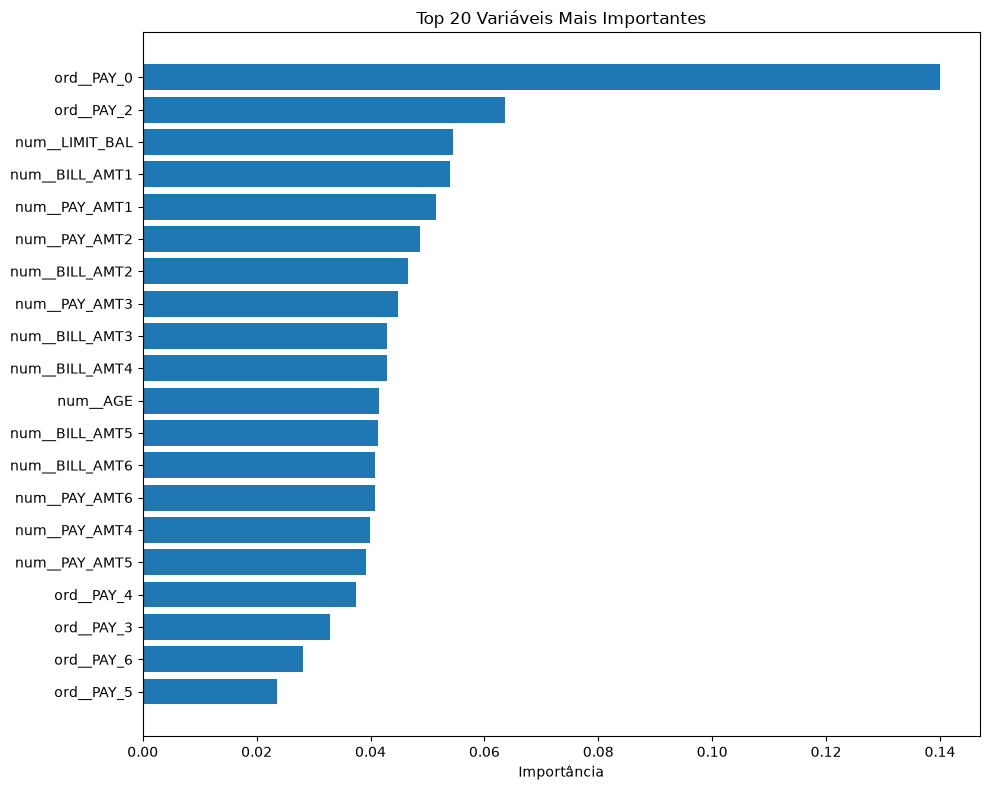

In [5]:
# ==================================================
# Gráfico Feature Importance
# ==================================================

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:20][::-1],
    importance["Importance"][:20][::-1]
)

plt.xlabel("Importância")

plt.title("Top 20 Variáveis Mais Importantes")

plt.tight_layout()

plt.show()

In [1]:
import shap

import joblib

best_model = joblib.load(
    "../models/random_forest_tuned_pipeline.pkl"
)

print("Modelo carregado com sucesso!")


# Dados transformados
X_test_transformed = (
    best_model
    .named_steps["preprocessor"]
    .transform(X_test))

# Modelo
rf = best_model.named_steps["classifier"]
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(
    shap_values[:, :, 1],
    X_test_transformed,
    feature_names=feature_names)

shap.plots.bar(
    shap.Explanation(
        values=shap_values[:, :, 1],
        data=X_test_transformed,
        feature_names=feature_names))

indice = list(feature_names).index("ord__PAY_0")

shap.dependence_plot(
    indice,
    shap_values[:, :, 1],
    X_test_transformed,
    feature_names=feature_names
)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test_transformed[0],
        feature_names=feature_names
    )
)

Modelo carregado com sucesso!


NameError: name 'X_test' is not defined

In [2]:
# ==================================================
# SHAP - Preparação dos dados
# ==================================================

import joblib
import shap
import pandas as pd
from sklearn.model_selection import train_test_split

# ==================================================
# Carrega o modelo treinado
# ==================================================

best_model = joblib.load(
    "../models/random_forest_tuned_pipeline.pkl"
)

print("Modelo carregado com sucesso!")

# ==================================================
# Leitura dos dados
# ==================================================

TARGET = "default payment next month"

df = pd.read_excel(
    r"C:\Users\T-Gamer\Desktop\igor\credit-default-api\data\raw\default_of_credit_card_clients.xls",
    header=1
)

# Remove ID
X = df.drop(columns=["ID", TARGET])
y = df[TARGET]

# ==================================================
# Reconstrói o mesmo Train/Test Split
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"X_test: {X_test.shape}")

# ==================================================
# Feature names
# ==================================================

feature_names = (
    best_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# ==================================================
# Transformação dos dados
# ==================================================

X_test_transformed = (
    best_model
    .named_steps["preprocessor"]
    .transform(X_test)
)

print(f"Dados transformados: {X_test_transformed.shape}")

# ==================================================
# Random Forest
# ==================================================

rf = best_model.named_steps["classifier"]

# ==================================================
# SHAP TreeExplainer
# ==================================================

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(
    X_test_transformed
)

print("SHAP calculado com sucesso!")
print("Tipo:", type(shap_values))

Modelo carregado com sucesso!
X_test: (6000, 23)
Dados transformados: (6000, 33)
SHAP calculado com sucesso!
Tipo: <class 'numpy.ndarray'>


In [3]:
print("Shape:", shap_values.shape)
print("Expected value:", explainer.expected_value)

Shape: (6000, 33, 2)
Expected value: [0.50020208 0.49979792]


In [4]:
# ==================================================
# Feature Importance - Random Forest
# ==================================================

import pandas as pd
import matplotlib.pyplot as plt

rf = best_model.named_steps["classifier"]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance.head(20))

           Feature  Importance
27      ord__PAY_0    0.140028
28      ord__PAY_2    0.063647
0   num__LIMIT_BAL    0.054415
2   num__BILL_AMT1    0.054034
8    num__PAY_AMT1    0.051572
9    num__PAY_AMT2    0.048688
3   num__BILL_AMT2    0.046625
10   num__PAY_AMT3    0.044894
4   num__BILL_AMT3    0.042983
5   num__BILL_AMT4    0.042928
1         num__AGE    0.041455
6   num__BILL_AMT5    0.041298
7   num__BILL_AMT6    0.040838
13   num__PAY_AMT6    0.040820
11   num__PAY_AMT4    0.039861
12   num__PAY_AMT5    0.039176
30      ord__PAY_4    0.037496
29      ord__PAY_3    0.032968
32      ord__PAY_6    0.028137
31      ord__PAY_5    0.023544


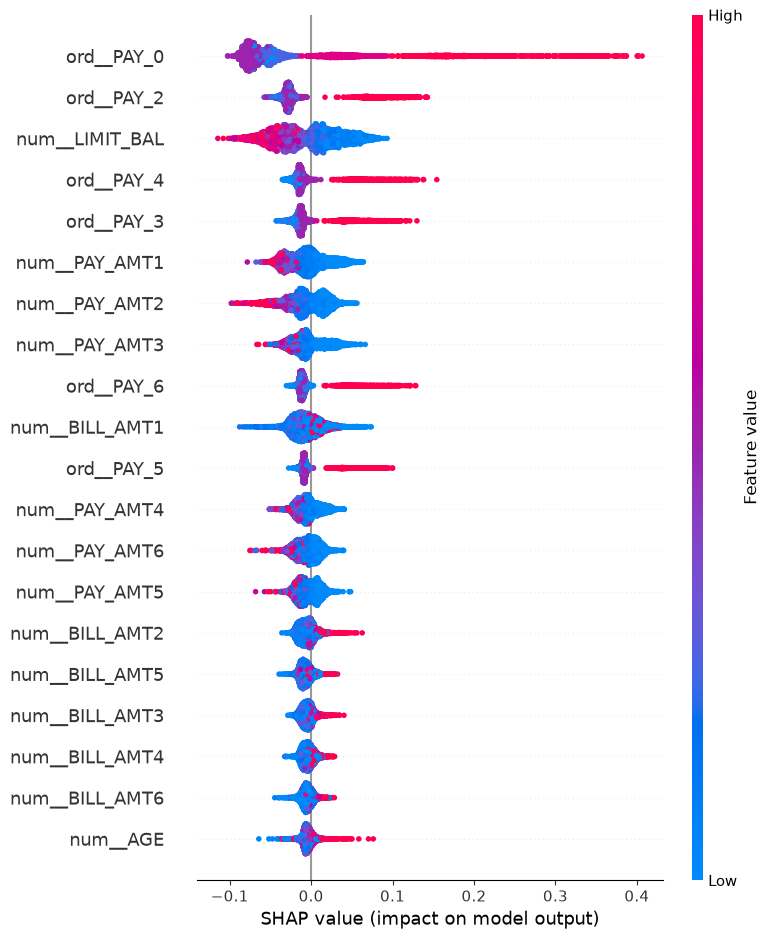

In [6]:
# ==================================================
# SHAP - Valores da Classe 1
# ==================================================

shap_class_1 = shap_values[:, :, 1]

# ==================================================
# SHAP Summary Plot
# ==================================================

shap.summary_plot(
    shap_class_1,
    X_test_transformed,
    feature_names=feature_names
)

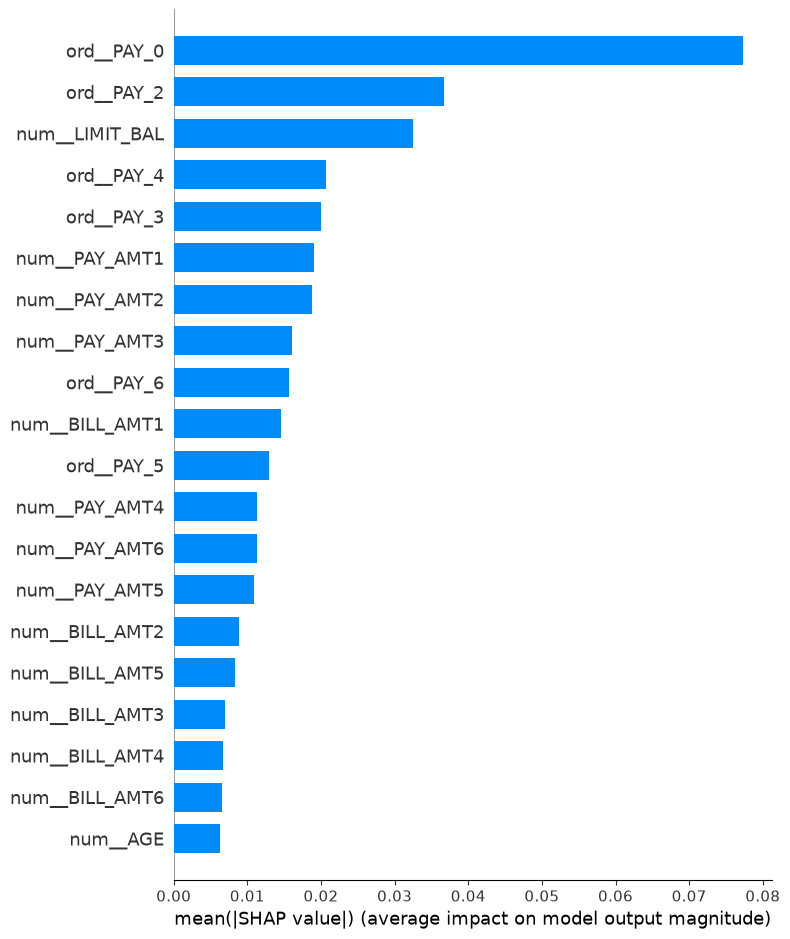

In [7]:
# ==================================================
# SHAP Feature Importance
# ==================================================

shap.summary_plot(
    shap_class_1,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

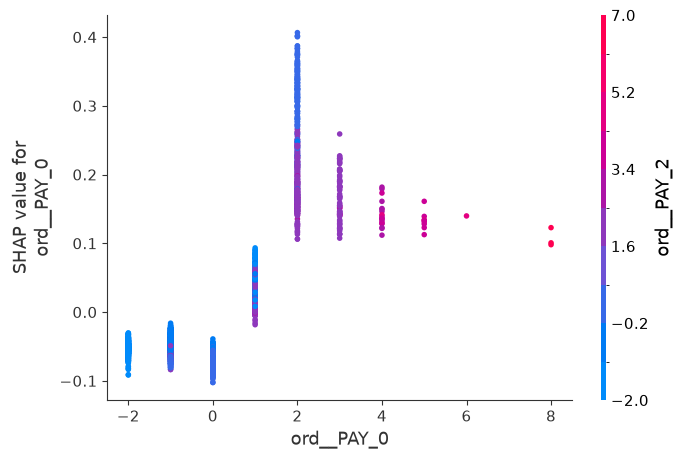

In [8]:
# ==================================================
# SHAP Dependence Plot - PAY_0
# ==================================================

indice_pay0 = list(feature_names).index("ord__PAY_0")

shap.dependence_plot(
    indice_pay0,
    shap_class_1,
    X_test_transformed,
    feature_names=feature_names
)

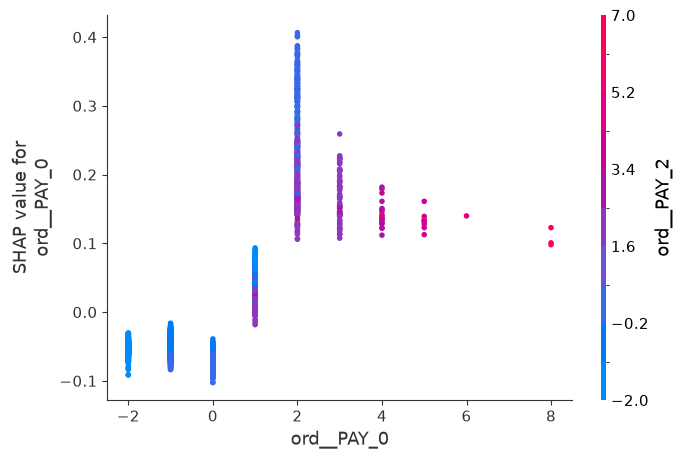

In [9]:
indice_pay0 = list(feature_names).index("ord__PAY_0")

shap.dependence_plot(
    indice_pay0,
    shap_class_1,
    X_test_transformed,
    feature_names=feature_names
)

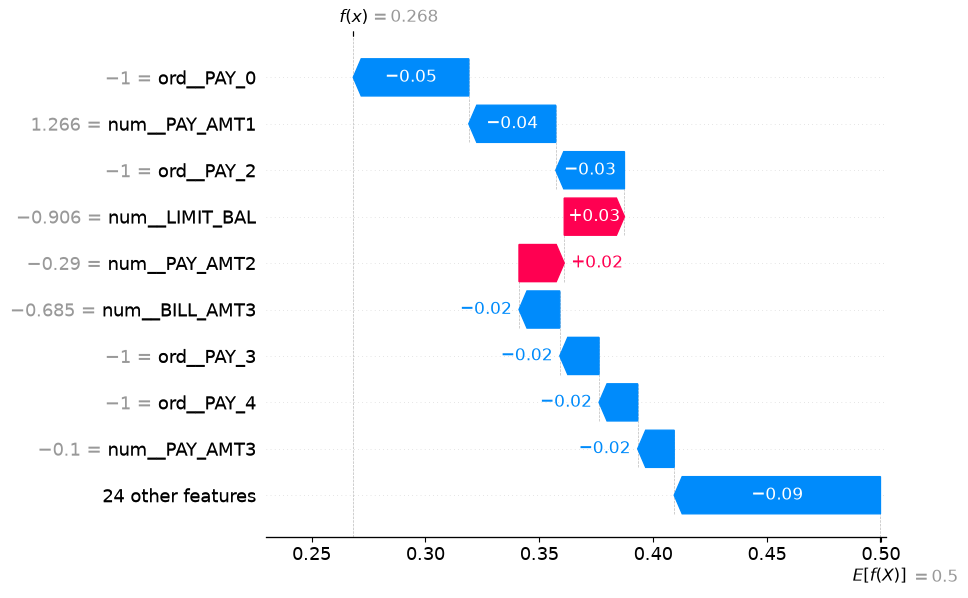

In [10]:
shap_explanation = shap.Explanation(
    values=shap_class_1[0],
    base_values=explainer.expected_value[1],
    data=X_test_transformed[0],
    feature_names=feature_names
)

shap.plots.waterfall(shap_explanation)